# Customer Segmentation Lab

**Question:** Can historical purchasing behavior reveal useful customer groups?

This educational portfolio project uses a public UCI dataset. It was developed with AI assistance; review the code and assumptions before presenting it. See `DATA.md` for the dataset citation, license, exact source hash, and transformations.

## 1. Setup
Run every cell in order with Python 3.12 and the project dependencies installed.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display, Image
from src.pipeline import main


## 2. Build recency, frequency, and monetary features
Customer IDs link purchases but are not predictive features. Missing IDs are excluded. Frequency counts distinct invoices, while spend sums positive sales. Recency is measured from one day after the final transaction date.

In [2]:
from src.data import load_data, clean_sales
from src.pipeline import make_rfm
raw, source_hash = load_data()
sales, audit = clean_sales(raw)
rfm, snapshot = make_rfm(sales)
print("Snapshot:", snapshot.date(), "Eligible customers:", len(rfm))
display(rfm.describe().round(2))

Snapshot: 2011-12-10 Eligible customers: 4338


,recency,frequency,monetary
count,4338.00,4338.00,4338.00
mean,93.06,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.75,5.00,1660.60
max,374.00,209.00,280206.02


## 3. Handle skew and scale
Large monetary values otherwise dominate Euclidean distance. The log(1+x) transform reduces skew; standardization then puts the three features on comparable scales. We do not remove high-spend customers just because they are unusual.

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
transformed = StandardScaler().fit_transform(np.log1p(rfm))
display(pd.DataFrame(transformed, columns=rfm.columns).describe().round(3))

,recency,frequency,monetary
count,4338.000,4338.000,4338.000
mean,0.000,-0.000,-0.000
std,1.000,1.000,1.000
min,-2.421,-0.955,-3.998
25%,-0.698,-0.955,-0.684
50%,0.072,-0.362,-0.065
75%,0.850,0.653,0.657
max,1.584,5.859,4.732


## 4. Compare cluster solutions
For k=2…6, use 20 K-means initializations and a fixed seed. Compare silhouette on a reproducible sample of up to 2,000 customers. Another seed gives a sensitivity check using adjusted Rand index; it does not test stability over time.

{
  "customers": 4338,
  "selected_k": 2,
  "comparisons": [
    {
      "k": 2,
      "silhouette": 0.4251876089244755,
      "seed_stability_ari": 1.0,
      "inertia": 6476.506937053552
    },
    {
      "k": 3,
      "silhouette": 0.329678829867433,
      "seed_stability_ari": 0.989647577287723,
      "inertia": 4858.078487594671
    },
    {
      "k": 4,
      "silhouette": 0.33021277287195977,
      "seed_stability_ari": 0.9558966572410037,
      "inertia": 3925.274472672854
    },
    {
      "k": 5,
      "silhouette": 0.3196949670376159,
      "seed_stability_ari": 0.9963209693288203,
      "inertia": 3269.0747590373144
    },
    {
      "k": 6,
      "silhouette": 0.3185322270556646,
      "seed_stability_ari": 0.9456695756202319,
      "inertia": 2840.653969257967
    }
  ]
}


,k,silhouette,seed_stability_ari,inertia
0,2,0.4252,1.0000,6476.5069
1,3,0.3297,0.9896,4858.0785
2,4,0.3302,0.9559,3925.2745
3,5,0.3197,0.9963,3269.0748
4,6,0.3185,0.9457,2840.6540


Selected k: 2


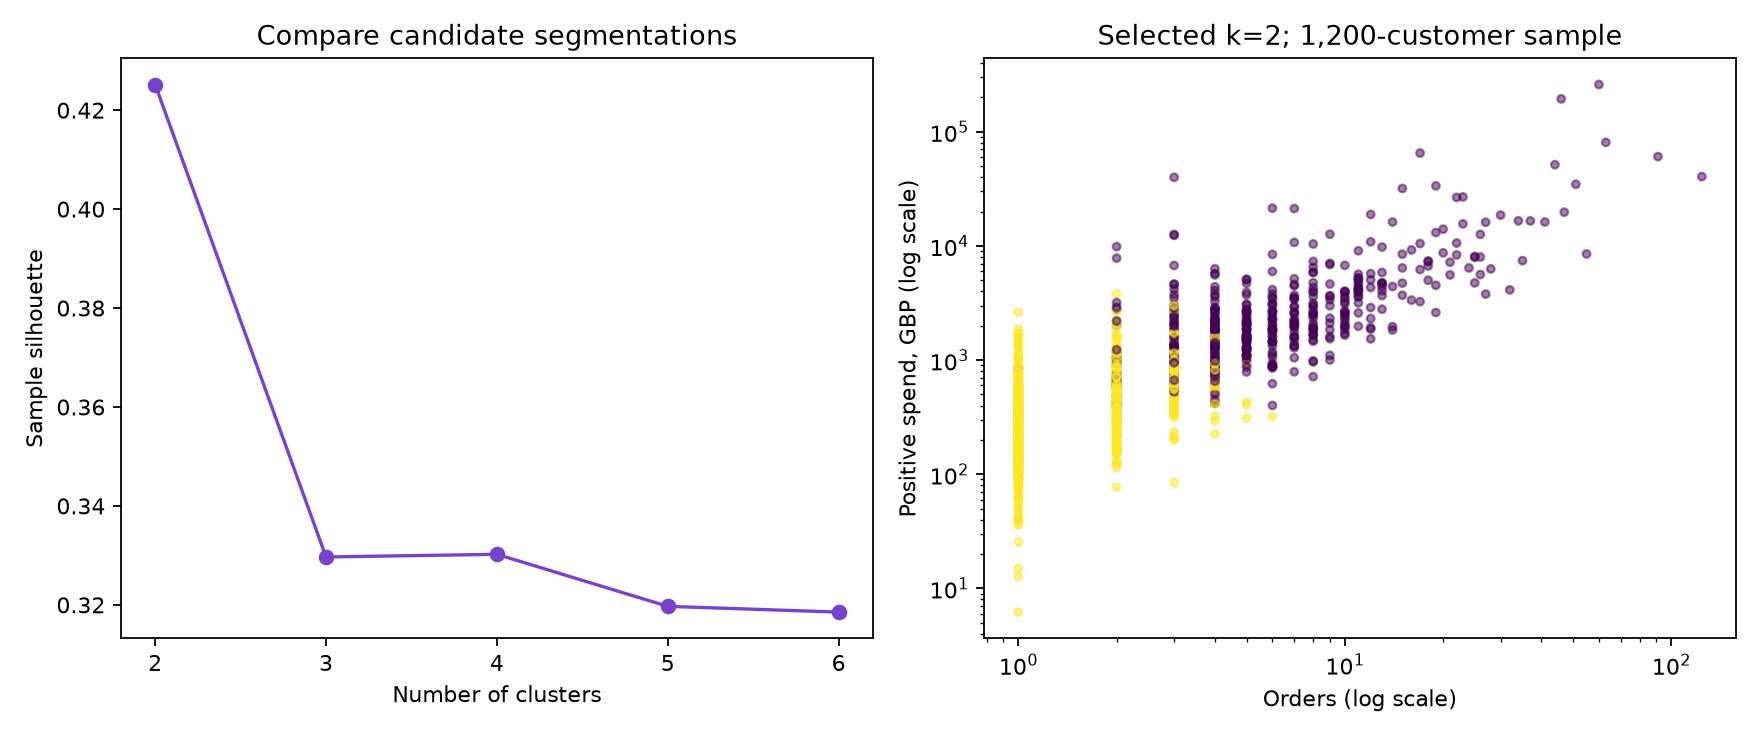

In [4]:
result = main()
display(pd.DataFrame(result["comparisons"]).round(4))
print("Selected k:", result["selected_k"])
display(Image(filename=str(ROOT / "reports/segments.png")))

## 5. Interpret the profiles
Use medians rather than means for typical customer behavior. Segment IDs have no intrinsic order. More detailed segmentations may help a business discussion but should not be described as objectively better simply because they have more groups.

In [5]:
profiles = pd.DataFrame(result["models"][str(result["selected_k"])]["profiles"])
display(profiles.round(2))
assert profiles.customers.sum() == result["customers"]
assert abs(profiles.share.sum() - 1) < 1e-10

,id,customers,share,recency,frequency,monetary,total_sales
0,0,1668,0.38,17.0,6.0,2058.17,7565611.80
1,1,2670,0.62,96.0,1.0,362.01,1321597.09


## 6. Conclusions and next work
The silhouette criterion prefers two broad groups here. The demo lets you compare 3–6 groups transparently rather than forcing a preferred story. There are no true segment labels, so classification accuracy is not applicable.

**Try it:** compare RFM quantile rules, test cluster stability at earlier snapshot dates, and evaluate proposed marketing actions in a controlled experiment. Include returns if the goal is net customer value.